In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression


In [11]:
np.random.seed(42)
num_samples = 500
years_of_experience = np.random.randint(2,21,size = num_samples)
slope = (200_000 - 60_000) / 18
intercept = 60_000
salaries = slope * years_of_experience + intercept + np.random.normal(0, 10_000, size = num_samples)
data = {
    'Years_of_Experience': years_of_experience, 
    'Salary': salaries}
df = pd.DataFrame(data)


In [12]:
df.head(5)

,Years_of_Experience,Salary
0,8,115037.780010
1,16,182309.972927
2,12,156442.408989
3,9,144753.562169
4,8,130798.818454


In [13]:
df.describe()

,Years_of_Experience,Salary
count,500.000000,500.000000
mean,10.616000,142570.011096
std,5.662922,44935.263058
min,2.000000,54881.134555
25%,5.750000,104426.300731
50%,10.000000,139865.032545
75%,16.000000,182341.125962
max,20.000000,241879.376204


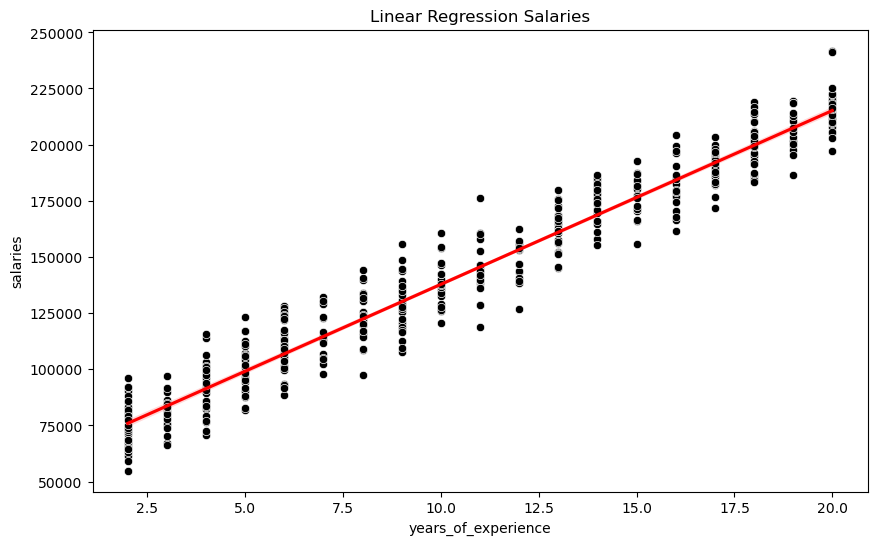

In [14]:
plt.figure(figsize= (10,6))
sns.scatterplot(
    x= 'Years_of_Experience',
    y = 'Salary',
    data = df,
    color = 'black'
)
sns.regplot(x= 'Years_of_Experience',
    y = 'Salary',
    data = df,
    scatter= False,
    color= 'red')

plt.xlabel('years_of_experience')
plt.ylabel('salaries')
plt.title('Linear Regression Salaries')
plt.show()


In [19]:
X = df[['Years_of_Experience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=123)

In [20]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [21]:
lr.score(X_train, y_train)

0.9501959579269998

In [22]:
lr.score(X_test, y_test)

0.9515935152065987

In [28]:
y_pred = lr.predict(X_test)

print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R2 Score: {r2_score(y_test, y_pred)}')


Mean Absolute Error: 7947.043660737006
Mean Squared Error: 103866413.79723129
R2 Score: 0.9515935152065987


In [29]:
lr.coef_

array([7771.41662417])

In [30]:
lr.intercept_

60034.50774510183

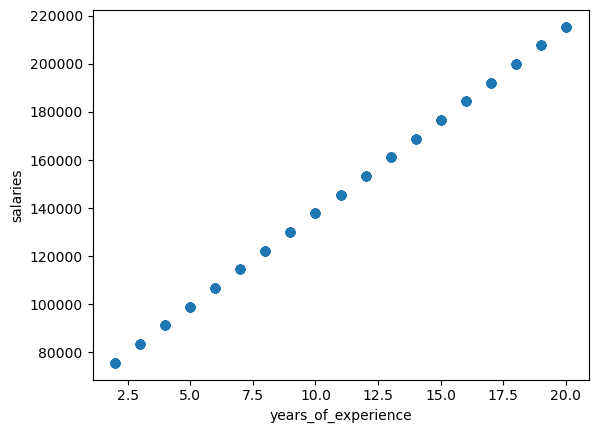

In [31]:
coefficients = lr.coef_
intercept = lr.intercept_

x = np.linspace(0, 20, 100)
y = coefficients*X + intercept

plt.scatter(X, y, label = f'y  = {coefficients[0]}x + {intercept}')
plt.xlabel('years_of_experience')
plt.ylabel('salaries')
plt.show()